<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/GroupAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Each members model and group self-created code

## Setup


In [1]:
import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings

np.random.seed(42)
tf.random.set_seed(42)

## Data Loading**

The dataset is download from UNB but colab cannot directly access to the link. Hence, we upload into a public google drive to download by using the url. (IDS 2017 | Datasets | Research | Canadian Institute for Cybersecurity | UNB, n.d.)

In [2]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo
From (redirected): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo&confirm=t&uuid=72388bbb-57a3-4832-9dec-d4483c104fff
To: /content/CIC-IDS2017.zip
100%|██████████| 235M/235M [00:02<00:00, 106MB/s]


Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Total rows after sampling: 320000
Saved to CICIDS2017_sampled.csv


In [3]:
# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,77689,4,8,6134,153,4686,0,1533.5,2209.736862,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,3659078,10,9,717,5821,363,0,71.7,121.708258,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,44176,76,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,8641,81,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1026,61,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


## Pre-processing

Data Cleaning

In [4]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))

Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'PortScan' 'Infiltration' 'DDoS' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Bot']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


Train-test split

In [5]:
# Features and raw labels
X = df_combined.drop(columns=['Label']).values
y_raw = df_combined['Label'].values

# Train-test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Train shape:", X_train.shape, y_train_raw.shape)
print("Test shape:", X_test.shape, y_test_raw.shape)


Train shape: (244055, 78) (244055,)
Test shape: (61014, 78) (61014,)


Balance Classes

In [6]:
# Total the label sample
#class_counts = df_combined['Label'].value_counts()
#print("Original class distribution:")
#print(class_counts)

# Find the label types which is existed the highest time
#majority_class = class_counts.idxmax()
#print("Majority class:", majority_class)

#Separate the highest existed label and anothers
#df_majority = df_combined[df_combined['Label'] == majority_class]
#df_minority = df_combined[df_combined['Label'] != majority_class]

#Undersample the majority class to match the total of the minority class (to maintain balance).
#df_majority_downsampled = resample(df_majority,
#                                   replace=False,
#                                   n_samples=len(df_minority),
#                                   random_state=42)

#df_balanced = pd.concat([df_majority_downsampled, df_minority])
#print("Balanced class distribution:")
#print(df_balanced['Label'].value_counts())

# Convert X_train to DataFrame and add Label
df_train = pd.DataFrame(X_train, columns=df_combined.columns[:-1])
df_train['Label'] = y_train_raw

# Identify majority class and minority classes
majority_class = df_train['Label'].value_counts().idxmax()
df_majority = df_train[df_train['Label'] == majority_class]
df_minority = df_train[df_train['Label'] != majority_class]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced training class distribution:")
print(df_train_balanced['Label'].value_counts())

# Separate features and labels
X_train_bal = df_train_balanced.drop('Label', axis=1).values
y_train_bal_raw = df_train_balanced['Label'].values

Balanced training class distribution:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


Features scaling

In [7]:
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

Label Encoding using One-Hot Encoding because the model we choose is neural network

In [8]:
# Print out all the column name
#print(df.columns.tolist())

# Remove all the space after and before the columns name
#df.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm again the columns name
#print(df.columns.tolist())

# Confirm the label types
#print("Unique Labels:", df['Label'].unique())

# Convert the unreadable text to readable
#df['Label'] = df['Label'].replace({
#    'Web Attack � Brute Force': 'Web Attack - Brute Force',
#    'Web Attack � XSS': 'Web Attack - XSS',
#    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
#})
# Above put in data cleaning places

ohe = OneHotEncoder(sparse_output=False)
y_train_bal = ohe.fit_transform(y_train_bal_raw.reshape(-1,1))
y_test = ohe.transform(y_test_raw.reshape(-1,1))


Document features

In [9]:
# Feature summary
feature_names = df_train_balanced.drop(columns=['Label']).columns.tolist()
print(f"\nNumber of features: {len(feature_names)}")
print("Feature names (first 10):", feature_names[:10])

# Check feature types
print("\nFeature types:")
print(df_train_balanced.dtypes.value_counts())

# Class distribution
class_counts = df_train_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (first 10): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Feature types:
float64    78
object      1
Name: count, dtype: int64

Class distribution table:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


## Model

### Define DNN （Group-self created)

In [ ]:
dropout_rate = 0.3
neurons = [128, 64, 32]

model = Sequential()
# Define input with Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(neurons[0], activation='relu'))
model.add(Dropout(dropout_rate))

# Second hidden layer
model.add(Dense(neurons[1], activation='relu'))
model.add(Dropout(dropout_rate))

# Third hidden layer
model.add(Dense(neurons[2], activation='relu'))
model.add(Dropout(dropout_rate))

# Output layer
model.add(Dense(y_train_bal.shape[1], activation='softmax'))

model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,943 (81.81 KB)

 Trainable params: 20,943 (81.81 KB)

 Non-trainable params: 0 (0.00 B)

### Define MLP (CY)

In [ ]:
#1. WIthout same train model
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score, precision_score, recall_score

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Build MLP model
mlp_model = Sequential([
    Input(shape=(X_train_bal.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(y_train_bal.shape[1], activation='softmax')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = mlp_model.fit(
    X_train_bal, y_train_bal,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# F1 Score (macro)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1 Score: {f1:.4f}")

# Macro-averaged precision and recall
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")

# Weighted-averaged precision and recall
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")

#2. same train model
# Compute class weights
y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Early stopping callback (optional)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = mlp_model.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_test_scaled, y_test),
    epochs=5,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 100)            │         7,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │           765 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,715 (53.57 KB)

 Trainable params: 13,715 (53.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4281 - loss: 2284432.5000 - val_accuracy: 0.5373 - val_loss: 104516.6719
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6566 - loss: 107483.5469 - val_accuracy: 0.4965 - val_loss: 13132.5400
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6185 - loss: 31007.2285 - val_accuracy: 0.4723 - val_loss: 2681.5872
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5771 - loss: 12438.5107 - val_accuracy: 0.3498 - val_loss: 499.1573
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5160 - loss: 7933.8667 - val_accuracy: 0.3470 - val_loss: 103.4064
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5448 - loss: 2765.1992 - val_accuracy: 0.0000e+00 - val_loss: 13.5001
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6140 - loss: 1973.4633 - val_accuracy: 0.0000e+00 - val_loss: 4.0098
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 

### Define CNN+BiLSTM+Transformer Model (Kok）

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# Reshape X_train for Conv1D/LSTM (expects 3D: [samples, timesteps, features])
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Input
inputs = Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

# --- CNN Block ---
x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)

# --- BiLSTM Block ---
x = Bidirectional(LSTM(32, return_sequences=True))(x)

# --- Transformer Block ---
attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = LayerNormalization(epsilon=1e-6)(x + attn_output)

# --- Pooling ---
x = GlobalAveragePooling1D()(x)

# --- Dense Layers (Simplified) ---
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# --- Output Layer ---
outputs = Dense(y_train_bal.shape[1], activation='softmax')(x)

# Build Model
model = Model(inputs, outputs)

# Print model summary
model.summary()

# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 4

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Overall Precision
overall_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Precision:", overall_precision)

# Overall Recall
overall_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Recall:", overall_recall)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 78, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 78, 32)    │        128 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 39, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 39, 64)    │     16,640 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 64)    │     33,216 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 39, 64)    │          0 │ bidirectional[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 39, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 15)        │      1,935 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,367 (235.81 KB)

 Trainable params: 60,367 (235.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 207s 72ms/step - accuracy: 0.7844 - loss: 0.6297 - val_accuracy: 0.9606 - val_loss: 0.1170
Epoch 2/4
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 187s 66ms/step - accuracy: 0.9450 - loss: 0.1677 - val_accuracy: 0.9668 - val_loss: 0.0916
Epoch 3/4


KeyboardInterrupt: 

### LTSM + ANN (Chuah)

In [ ]:
# --- Imports ---
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# --- 1) Train/Val/Test Split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train_raw,
    test_size=0.2,
    stratify=y_train_raw,
    random_state=42
)

# --- 2) One-Hot Encode Labels ---
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
y_tr  = enc.fit_transform(y_tr_raw.reshape(-1,1))
y_val = enc.transform(y_val_raw.reshape(-1,1))
y_test = enc.transform(y_test_raw.reshape(-1,1))

num_classes = y_tr.shape[1]   # should be 15
print("Classes:", enc.categories_[0].tolist())

# --- 3) Reshape Features for LSTM ---
X_tr_3d  = X_tr.reshape(X_tr.shape[0],  X_tr.shape[1],  1)
X_val_3d = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_te_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# --- 4) Define LSTM Model ---
lstm_model = Sequential([
    LSTM(64, input_shape=(X_tr_3d.shape[1], 1), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')   # multiclass output
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5) Callbacks ---
earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# --- 6) Train ---
history = lstm_model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=10, batch_size=64,
    callbacks=[earlystop, reducelr],
    verbose=1
)

# --- 7) Evaluate ---
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

y_proba = lstm_model.predict(X_te_3d)   # (N, 15)
y_pred  = y_proba.argmax(axis=1)        # class indices
y_true  = y_test.argmax(axis=1)         # class indices

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("📊 Core Metrics (Macro)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_true, y_pred, digits=4))

# --- 8) Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — LSTM (Multiclass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
 830/3051 ━━━━━━━━━━━━━━━━━━━━ 1:36 44ms/step - accuracy: 0.8255 - loss: 0.6815

### Define TabTransformer (Yap)

In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Dropout, LayerNormalization, MultiHeadAttention, Lambda
from tensorflow.keras.models import Model
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve
)
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize

# -------------------------------
# TabTransformer Block
# -------------------------------
def tab_transformer_block(inputs, n_heads=2, d_model=32, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=n_heads, key_dim=d_model)(inputs, inputs)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ffn_output = Dense(d_model*4, activation='relu')(out1)
    ffn_output = Dense(d_model)(ffn_output)
    ffn_output = Dropout(dropout)(ffn_output)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    return out2

# -------------------------------
# TabTransformer Classifier
# -------------------------------
def build_tabtransformer_classifier(input_dim, num_classes, embed_dim=32, n_blocks=2):
    data_input = Input(shape=(input_dim,))
    x = Dense(embed_dim)(data_input)
    x = Lambda(lambda t: tf.expand_dims(t, axis=1))(x)  # shape -> (batch, 1, embed_dim)

    for _ in range(n_blocks):
        x = tab_transformer_block(x, n_heads=2, d_model=embed_dim)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    return Model(data_input, output)

# -------------------------------
# Build and Compile
# -------------------------------
y_train_int = np.argmax(y_train_bal, axis=1)
y_test_int = np.argmax(y_test, axis=1)
num_classes = len(np.unique(y_train_int))
classifier = build_tabtransformer_classifier(input_dim=X_train_bal_scaled.shape[1], num_classes=num_classes)
classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# -------------------------------
# Training
# -------------------------------
X_train_aug = np.vstack([X_train_bal_scaled])
y_train_aug = np.hstack([y_train_int])

history = classifier.fit(
    X_train_aug,
    tf.keras.utils.to_categorical(y_train_aug, num_classes=num_classes),
    batch_size=64,
    epochs=10,
    validation_split=0.1
)

# -------------------------------
# Evaluation
# -------------------------------
y_pred_prob = classifier.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test_int, y_pred, average="macro")
acc = accuracy_score(y_test_int, y_pred)

print("\nCore Metrics (Macro):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_int, y_pred, digits=4))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test_int, y_pred)
class_names = df_combined['Label'].unique()

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# ROC Curve (One-vs-Rest)
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_label in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_test_int == i).astype(int), y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------------
# Precision-Recall Curve
# -------------------------------
plt.figure(figsize=(8, 6))
for i, class_label in enumerate(class_names):
    precision_curve, recall_curve, _ = precision_recall_curve((y_test_int == i).astype(int), y_pred_prob[:, i])
    plt.plot(recall_curve, precision_curve, label=f"{class_label}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

### Define CNN Model （TWX)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Conv1D, BatchNormalization,
    MaxPooling1D, GlobalAveragePooling1D, Dropout, Dense
)

# Build CNN that accepts flat features and reshapes internally
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Reshape((X_train.shape[1], 1)),            # (timesteps/features, channels)

    # Conv blocks
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),

    # Head
    GlobalAveragePooling1D(),
    Dropout(0.3),

    Dense(y_train_bal.shape[1], activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 78, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 78, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 78, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 39, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 39, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,455 (302.56 KB)

 Trainable params: 76,815 (300.06 KB)

 Non-trainable params: 640 (2.50 KB)

## Training

Set hyperparameters, compile the model, and fit it to the data.

In [ ]:
# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 5

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9278 - loss: 0.3025 - val_accuracy: 0.9708 - val_loss: 0.0801
Epoch 2/5
 288/2795 ━━━━━━━━━━━━━━━━━━━━ 1:44 42ms/step - accuracy: 0.9734 - loss: 0.0886

## Evaluation


Prediction

In [ ]:
# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

Evaluation Metrics

In [ ]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Overall Precision
overall_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Precision:", overall_precision)

# Overall Recall
overall_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Recall:", overall_recall)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Weighted F1
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print("Weighted F1 Score:", weighted_f1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa Score:", kappa)

# Multi-class ROC Curve
n_classes = y_test.shape[1]
plt.figure(figsize=(12, 10))
for i in range(n_classes):
    if y_test[:, i].sum() == 0 or np.all(y_pred_probs[:, i] == 0):
        continue
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

## Save

Save the model

In [ ]:
# Save model
model.save("cicids2017_model.keras")
print("Model saved as cicids2017_model.keras")

# Save test features
pd.DataFrame(X_test, columns=feature_names).to_csv("X_test.csv", index=False)
print("Test features saved as X_test.csv")

# Save test labels (convert from one-hot to integer)
y_labels = np.argmax(y_test, axis=1)
pd.DataFrame(y_labels, columns=['Label']).to_csv("y_test_labels.csv", index=False)
print("Test labels saved as y_test_labels.csv")

# Save feature names for reference
pd.DataFrame(feature_names, columns=['Feature']).to_csv("feature_names.csv", index=False)
print("Feature names saved as feature_names.csv")

Model saved as cicids2017_model.keras
Test features saved as X_test.csv
Test labels saved as y_test_labels.csv
Feature names saved as feature_names.csv


Verdict

In [ ]:
print(f"Verdict: Achieved Accuracy = {accuracy:.4f}, Macro F1 = {macro_f1:.4f}. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.")


Verdict: Achieved Accuracy = 0.9853, Macro F1 = 0.5955. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.


# So, In the final comparason with our group self-created, and each of our models, the accuracy of LTSM+ANN is the highest. Hence, we choose it in our final.

# Final

# 1. Setup

In [ ]:

import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings

np.random.seed(42)
tf.random.set_seed(42)

# 2. Data Loading

In [ ]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo
From (redirected): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo&confirm=t&uuid=b0ab6315-133b-4830-b592-6cde130354d2
To: /content/CIC-IDS2017.zip
100%|██████████| 235M/235M [00:01<00:00, 144MB/s]


Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Total rows after sampling: 320000
Saved to CICIDS2017_sampled.csv


In [ ]:

# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,77689,4,8,6134,153,4686,0,1533.5,2209.736862,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,3659078,10,9,717,5821,363,0,71.7,121.708258,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,44176,76,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,8641,81,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1026,61,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


# 3. Pre-processing

In [ ]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))


Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'PortScan' 'Infiltration' 'DDoS' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Bot']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


In [ ]:
# === Define feature names (all columns except Label) ===
feature_names = df_combined.drop(columns=['Label']).columns.tolist()
print("Number of features:", len(feature_names))
print("First 10 feature names:", feature_names[:10])


Number of features: 78
First 10 feature names: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


# 4. Train-test split

In [ ]:
# Features and raw labels
X = df_combined.drop(columns=['Label']).values
y_raw = df_combined['Label'].values

# Train-test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Train shape:", X_train.shape, y_train_raw.shape)
print("Test shape:", X_test.shape, y_test_raw.shape)

Train shape: (244055, 78) (244055,)
Test shape: (61014, 78) (61014,)


# 5.Balance Classes

In [ ]:

df_train = pd.DataFrame(X_train, columns=df_combined.columns[:-1])
df_train['Label'] = y_train_raw

# Identify majority class and minority classes
majority_class = df_train['Label'].value_counts().idxmax()
df_majority = df_train[df_train['Label'] == majority_class]
df_minority = df_train[df_train['Label'] != majority_class]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced training class distribution:")
print(df_train_balanced['Label'].value_counts())

# Separate features and labels
X_train_bal = df_train_balanced.drop('Label', axis=1).values
y_train_bal_raw = df_train_balanced['Label'].values

Balanced training class distribution:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


# 6. Label Encoding using One-Hot Encoding because the model we choose is neural network

In [ ]:
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


ohe = OneHotEncoder(sparse_output=False)
y_train_bal = ohe.fit_transform(y_train_bal_raw.reshape(-1,1))
y_test = ohe.transform(y_test_raw.reshape(-1,1))

# 7. Features scaling

In [ ]:
# Feature summary
feature_names = df_train_balanced.drop(columns=['Label']).columns.tolist()
print(f"\nNumber of features: {len(feature_names)}")
print("Feature names (first 10):", feature_names[:10])

# Check feature types
print("\nFeature types:")
print(df_train_balanced.dtypes.value_counts())

# Class distribution
class_counts = df_train_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (first 10): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Feature types:
float64    78
object      1
Name: count, dtype: int64

Class distribution table:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


In [ ]:
# --- 1) Train/Val/Test Split ---
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

X_tr, X_val, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train_raw,
    test_size=0.2,
    stratify=y_train_raw,
    random_state=42
)


In [ ]:
# --- 2) One-Hot Encode Labels ---
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
y_tr  = enc.fit_transform(y_tr_raw.reshape(-1,1))
y_val = enc.transform(y_val_raw.reshape(-1,1))
y_test = enc.transform(y_test_raw.reshape(-1,1))

num_classes = y_tr.shape[1]   # should be 15
print("Classes:", enc.categories_[0].tolist())

# --- 3) Reshape Features for LSTM ---
X_tr_3d  = X_tr.reshape(X_tr.shape[0],  X_tr.shape[1],  1)
X_val_3d = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_te_3d  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


# 8. LSTM-ANN

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
model = Sequential([
    LSTM(64, input_shape=(X_tr_3d.shape[1], 1), return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')   # multiclass output
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,287 (87.06 KB)

 Trainable params: 22,159 (86.56 KB)

 Non-trainable params: 128 (512.00 B)

# Train Model

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
earlystop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# --- 6) Train ---
history = model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_val_3d, y_val),
    epochs=10, batch_size=64,
    callbacks=[earlystop, reducelr],
    verbose=1
)

Epoch 1/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 153s 49ms/step - accuracy: 0.9176 - loss: 0.3233 - val_accuracy: 0.9836 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 2/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 230s 58ms/step - accuracy: 0.9827 - loss: 0.0779 - val_accuracy: 0.9880 - val_loss: 0.0537 - learning_rate: 0.0010
Epoch 3/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 181s 51ms/step - accuracy: 0.9843 - loss: 0.0652 - val_accuracy: 0.9903 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 4/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 206s 53ms/step - accuracy: 0.9877 - loss: 0.0514 - val_accuracy: 0.9908 - val_loss: 0.0404 - learning_rate: 0.0010
Epoch 5/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 156s 51ms/step - accuracy: 0.9875 - loss: 0.0493 - val_accuracy: 0.9913 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 6/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 202s 51ms/step - accuracy: 0.9892 - loss: 0.0420 - val_accuracy: 0.9922 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 7/10
3051/3051 ━━━━━━━━━━━━━━━━━━━━ 194s 49ms/step -

# 9. Save Model

In [ ]:
# === Save model, scaler, and metadata after training ===
import joblib, json

# Save trained model
model.save("cicids2017_lstm_model.keras")
print("✅ Model saved to cicids2017_lstm_model.keras")

# Save scaler (already fitted on training data)
joblib.dump(scaler, "ids_scaler.pkl")
print("✅ Scaler saved to ids_scaler.pkl")

# Save metadata (features + exact class order from encoder)
bundle = {
    "feature_order": feature_names,             # feature names except Label
    "class_names": enc.categories_[0].tolist()  # exact encoder label order
}
with open("ids_meta.json", "w") as f:
    json.dump(bundle, f)
print("✅ Metadata saved to ids_meta.json")



✅ Model saved to cicids2017_lstm_model.keras
✅ Scaler saved to ids_scaler.pkl
✅ Metadata saved to ids_meta.json


# 10.Evaluation: Accuracy, Precision, Recall, F1-score, ROC–AUC

In [ ]:
# === Predict on test set ===
y_proba = model.predict(X_te_3d, verbose=0)   # (N, num_classes)
y_true_cls = y_test.argmax(axis=1)            # true class indices
y_pred_cls = y_proba.argmax(axis=1)           # predicted class indices


1907/1907 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step
📊 Core Metrics (Macro)
Accuracy:  0.9920
Precision: 0.6495
Recall:    0.5947
F1-score:  0.6049

Classification report (per class):
              precision    recall  f1-score   support

           0     0.9933    0.9976    0.9954     49837
           1     1.0000    0.2857    0.4444        77
           2     0.9989    0.9982    0.9986      4562
           3     0.8600    0.7611    0.8075       113
           4     0.9809    0.9494    0.9649      2057
           5     0.6456    0.8095    0.7183        63
           6     0.7714    0.8308    0.8000        65
           7     0.8696    1.0000    0.9302       120
           9     0.0000    0.0000    0.0000         1
          10     0.9914    0.9954    0.9934      3936
          11     0.9815    0.6974    0.8154        76
          12     0.0000    0.0000    0.0000        73
          13     0.0000    0.0000    0.0000         1
          14     0.0000    0.0000    0.0000        33

    accuracy

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


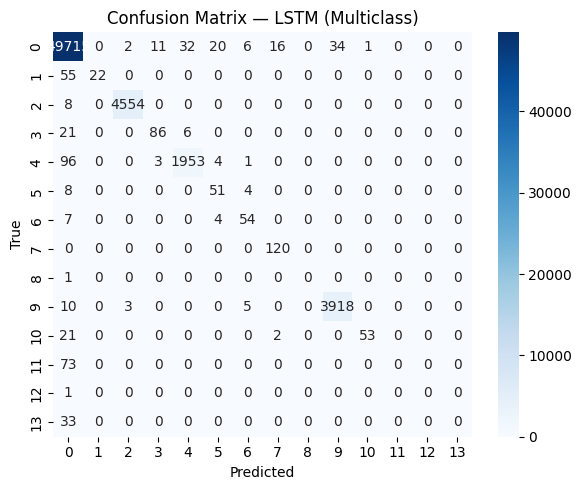

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

y_proba = model.predict(X_te_3d)   # (N, 15)
y_pred  = y_proba.argmax(axis=1)        # class indices
y_true  = y_test.argmax(axis=1)         # class indices

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("📊 Core Metrics (Macro)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report (per class):")
print(classification_report(y_true, y_pred, digits=4))

# --- 8) Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — LSTM (Multiclass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report
)

# If not already defined:
y_true_cls = y_test.argmax(axis=1)
y_pred_cls = y_proba.argmax(axis=1)

# ---- Sanity checks ----
assert y_test.ndim == 2 and y_proba.ndim == 2, "y_test and y_proba must be (N, K)"
assert y_test.shape == y_proba.shape, "Shapes must match"
if np.isnan(y_proba).any():
    print("⚠️ y_proba contains NaNs")

# probabilities roughly sum to 1?
row_sums = y_proba.sum(axis=1)
if not np.allclose(row_sums.mean(), 1.0, atol=1e-3):
    print(f"⚠️ mean row-sum of probs is {row_sums.mean():.4f} (expected ~1.0)")

# ---- Per-class AUCs (skip classes with only positives or only negatives) ----
support = y_test.sum(axis=0).astype(float)           # positives per class
neg_support = y_test.shape[0] - support              # negatives per class
valid = (support > 0) & (neg_support > 0)

per_class_auc = np.full(y_test.shape[1], np.nan)
for k in range(y_test.shape[1]):
    if valid[k]:
        per_class_auc[k] = roc_auc_score(y_test[:, k], y_proba[:, k])

macro_auc = np.nanmean(per_class_auc)  # average over valid classes only
den = np.nansum(support)
weighted_auc = (np.nansum(per_class_auc * support) / den) if den > 0 else np.nan

print("Per-class AUC (NaN → class absent in test or only one label present):")
print(per_class_auc)

# Try sklearn's macro OvR too (may return nan if any invalid class exists)
try:
    skl_macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
except Exception as e:
    skl_macro_auc = np.nan
    print("sklearn OvR macro AUC unavailable:", e)

# ---- Core metrics (macro) ----
acc = accuracy_score(y_true_cls, y_pred_cls)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true_cls, y_pred_cls, average='macro', zero_division=0
)

print("\n📊=============== Core Performance Metrics (Macro) ===============📊")
print("Accuracy: ", f"{acc:.4f}")
print("Precision:", f"{prec:.4f}")
print("Recall:   ", f"{rec:.4f}")
print("F1-score: ", f"{f1:.4f}")
print("ROC-AUC (macro over valid classes):",
      "NaN" if np.isnan(macro_auc) else f"{macro_auc:.4f}")



Per-class AUC (NaN → class absent in test or only one label present):
[0.99906441 0.99195955 0.99996287 0.99931501 0.99972554 0.99893748
 0.99979352 0.99996675        nan 0.99196892 0.99978111 0.99418369
 0.9955261  0.93793126 0.99716752]

📊=============== Core Performance Metrics (Macro) ===============📊
Accuracy:  0.9920
Precision: 0.6495
Recall:    0.5947
F1-score:  0.6049
ROC-AUC (macro over valid classes): 0.9932


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [ ]:
# --- Save Model & Artifacts ---
import pandas as pd
import numpy as np

# Save trained model
model.save("cicids2017_lstm_model.keras")
print("Model saved as cicids2017_lstm_model.keras")

# Save test features
pd.DataFrame(X_test, columns=feature_names).to_csv("X_test.csv", index=False)
print("Test features saved as X_test.csv")

# Save test labels (convert from one-hot to integer if needed)
if y_test.ndim == 2:  # one-hot
    y_labels = np.argmax(y_test, axis=1)
else:  # already integers
    y_labels = y_test
pd.DataFrame(y_labels, columns=['Label']).to_csv("y_test_labels.csv", index=False)
print("Test labels saved as y_test_labels.csv")

# Save feature names for reference
pd.DataFrame(feature_names, columns=['Feature']).to_csv("feature_names.csv", index=False)
print("Feature names saved as feature_names.csv")


Model saved as cicids2017_lstm_model.keras
Test features saved as X_test.csv
Test labels saved as y_test_labels.csv
Feature names saved as feature_names.csv


In [ ]:
# --- Verdict ---
def fmt(x):
    return "NaN" if (x is None or (isinstance(x, float) and np.isnan(x))) else f"{x:.4f}"

print("📊 Final Verdict")
print(f"Accuracy        = {acc:.4f}")
print(f"Macro Precision = {prec:.4f}")
print(f"Macro Recall    = {rec:.4f}")
print(f"Macro F1        = {f1:.4f}")
print(f"Macro ROC-AUC   = {fmt(macro_auc)}")
print(f"Weighted ROC-AUC= {fmt(weighted_auc)}")

# Tailored summary
summary = []
# Strong overall accuracy
if acc >= 0.99:
    summary.append("excellent overall accuracy")
elif acc >= 0.97:
    summary.append("strong overall accuracy")
else:
    summary.append("moderate overall accuracy")

# AUC interpretation
if (macro_auc is not None) and (not np.isnan(macro_auc)):
    if macro_auc >= 0.99:
        summary.append("very high separability (macro AUC)")
    elif macro_auc >= 0.97:
        summary.append("high separability (macro AUC)")




print("Overall:", "; ".join(summary) + ".")


📊 Final Verdict
Accuracy        = 0.9920
Macro Precision = 0.6495
Macro Recall    = 0.5947
Macro F1        = 0.6049
Macro ROC-AUC   = 0.9932
Weighted ROC-AUC= 0.9992
Overall: excellent overall accuracy; very high separability (macro AUC).


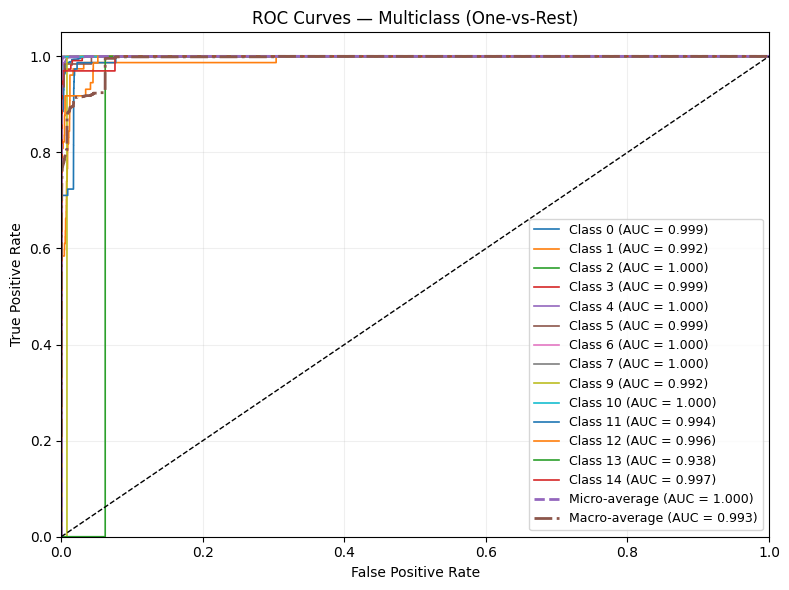

⚠️ Skipped classes (no positives or no negatives in y_test): ['Class 8']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Preconditions ---
assert y_test.ndim == 2 and y_proba.ndim == 2, "y_test and y_proba must be (N, K)"
assert y_test.shape == y_proba.shape, "y_test and y_proba must have same shape"
num_classes = y_test.shape[1]
names = class_names if 'class_names' in globals() and len(class_names) == num_classes else [f"Class {i}" for i in range(num_classes)]

# --- Per-class ROC (skip invalid classes) ---
fpr, tpr, roc_auc = {}, {}, {}
valid_mask = np.ones(num_classes, dtype=bool)
skipped = []

for i in range(num_classes):
    y_true_i = y_test[:, i]
    y_score_i = y_proba[:, i]
    # must have both pos and neg for ROC
    if (y_true_i.sum() == 0) or (y_true_i.sum() == len(y_true_i)):
        valid_mask[i] = False
        skipped.append(names[i])
        continue
    fpr[i], tpr[i], _ = roc_curve(y_true_i, y_score_i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Micro-average ROC ---
# Flatten all classes to compute micro ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --- Macro-average ROC (over valid classes only) ---
valid_indices = np.where(valid_mask)[0]
if len(valid_indices) > 0:
    # Aggregate all FPR points
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_indices]))
    # Interpolate TPR for each class and average
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_indices:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid_indices)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
else:
    fpr["macro"], tpr["macro"], roc_auc["macro"] = None, None, np.nan

# --- Plot ---
plt.figure(figsize=(8, 6))

# Plot per-class curves (limit legend clutter if needed)
max_classes_to_plot = num_classes  # change e.g. to 8 if too cluttered
count_plotted = 0
for i in range(num_classes):
    if i in valid_indices and count_plotted < max_classes_to_plot:
        plt.plot(fpr[i], tpr[i], lw=1.2, label=f"{names[i]} (AUC = {roc_auc[i]:.3f})")
        count_plotted += 1

# Plot micro and macro
plt.plot(fpr["micro"], tpr["micro"], lw=2.0, linestyle="--", label=f"Micro-average (AUC = {roc_auc['micro']:.3f})")
if fpr["macro"] is not None:
    plt.plot(fpr["macro"], tpr["macro"], lw=2.0, linestyle="-.", label=f"Macro-average (AUC = {roc_auc['macro']:.3f})")

# Diagonal
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.title("ROC Curves — Multiclass (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", fontsize=9, ncol=1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=200)
plt.show()

if skipped:
    print("⚠️ Skipped classes (no positives or no negatives in y_test):", skipped)


Steamlit （GUI)

In [ ]:

STREAMLIT_PATH = "/content/app.py"
APP_CODE = r"""
import os, json
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import streamlit as st
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.preprocessing import label_binarize

# ---- Streamlit config must be first ----
st.set_page_config(page_title="CIC-IDS2017 – IDS LSTM Inference", page_icon="🛡️", layout="wide")

MODEL_PATH = "cicids2017_lstm_model.keras" # <- LSTM model file
SCALER_PATH = "ids_scaler.pkl"
META_PATH   = "ids_meta.json"

# 🔄 Add this block here
if st.sidebar.button("🔄 Force reload assets"):
    st.cache_resource.clear()
    st.rerun()
# ---------- Load assets ----------
@st.cache_resource
def load_assets():
    model  = tf.keras.models.load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)  # StandardScaler object
    with open(META_PATH, "r") as f:
        meta = json.load(f)
    return model, scaler, meta["feature_order"], meta["class_names"]

model, scaler, FEATURE_ORDER, CLASS_NAMES = load_assets()

# ---------- Preprocess ----------
def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    for c in df.columns:
        if c in FEATURE_ORDER:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def ensure_features(df: pd.DataFrame) -> pd.DataFrame:
    for c in FEATURE_ORDER:
        if c not in df.columns:
            df[c] = np.nan
    return df[FEATURE_ORDER]

def fill_missing(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_numeric_dtype(out[c]):
            med = out[c].median()
            out[c] = out[c].fillna(0.0 if pd.isna(med) else med)
        else:
            out[c] = out[c].fillna("")
    return out

def predict_core(df_features: pd.DataFrame) -> pd.DataFrame:
    # 1) to numeric, align, impute
    df_num   = coerce_numeric(df_features)
    df_ready = ensure_features(df_num)
    df_ready = fill_missing(df_ready)

    # 2) scale to 2-D, then reshape to 3-D for LSTM (N, timesteps=n_features, 1)
    X2d = scaler.transform(df_ready.values)
    X3d = X2d.reshape(X2d.shape[0], X2d.shape[1], 1)

    # 3) predict
    probs = model.predict(X3d, verbose=0)
    top_i = probs.argmax(axis=1)
    top_p = probs.max(axis=1)
    top_l = [CLASS_NAMES[i] for i in top_i]

    out = pd.DataFrame({"predicted_label": top_l, "top1_prob": top_p})
    prob_df = pd.DataFrame(probs, columns=[f"prob_{c}" for c in CLASS_NAMES])
    out = pd.concat([out, prob_df], axis=1)
    return out

def compute_metrics(y_true_labels: pd.Series, probs: np.ndarray, class_names: list[str]):
    # Accuracy, Precision, Recall, F1 (macro), ROC-AUC (macro OVR).
    mask = y_true_labels.isin(class_names)
    y_true_filtered = y_true_labels[mask].astype(str)
    probs_valid = probs[mask.values]

    kept = int(mask.sum())
    dropped = int(len(y_true_labels) - kept)
    if kept == 0:
        return {"accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan,
                "kept": kept, "dropped": dropped}

    name_to_idx = {c: i for i, c in enumerate(class_names)}
    y_true_idx = np.array([name_to_idx[l] for l in y_true_filtered], dtype=int)
    y_pred_idx = probs_valid.argmax(axis=1)

    acc = accuracy_score(y_true_idx, y_pred_idx)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_idx, y_pred_idx, average="macro", zero_division=0
    )

    try:
        y_true_bin = label_binarize(y_true_filtered, classes=class_names)
        roc_auc = roc_auc_score(y_true_bin, probs_valid, average="macro", multi_class="ovr")
    except Exception:
        roc_auc = np.nan

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": roc_auc,
            "kept": kept, "dropped": dropped}

def read_table_local(path: str) -> pd.DataFrame:
    path = str(path)
    if path.lower().endswith(".parquet"):
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False, compression="infer")

# ---------- UI ----------
st.title("🛡️ CIC-IDS2017 – IDS LSTM Inference (Streamlit)")

with st.expander("ℹ️ Model & Schema", expanded=False):
    st.write(f"**Classes ({len(CLASS_NAMES)}):** {', '.join(CLASS_NAMES)}")
    st.write(f"**Features expected ({len(FEATURE_ORDER)}):** {len(FEATURE_ORDER)}")
    st.code(", ".join(FEATURE_ORDER[:30]) + (" ..." if len(FEATURE_ORDER) > 30 else ""), language="text")

tab_batch, tab_single = st.tabs(["📁 Batch (Local file path only)", "🧪 Single Row (JSON)"])

# ---- Batch: local path only ----
with tab_batch:
    st.caption("Reads a dataset already inside Colab/Drive — no browser uploads.")
    default_path = "/content/CIC_IDS2017_cleaned.csv"
    path = st.text_input("Local file path (.csv / .csv.gz / .parquet)", value=default_path)
    limit = st.number_input("Optional preview/predict first N rows (0 = all)", min_value=0, value=0, step=1000)

    if st.button("Run prediction on local file"):
        if not os.path.exists(path):
            st.error(f"Path not found: {path}")
        else:
            try:
                # Load
                df = read_table_local(path)
                if limit and limit > 0:
                    df = df.head(int(limit))


                st.write("Unique labels in CSV:", df["Label"].unique())
                st.write("Class names from model:", CLASS_NAMES)
                # Inputs for model (drop Label if present)
                df_inputs = df.drop(columns=["Label"]) if "Label" in df.columns else df.copy()
                st.write(f"Loaded **{len(df_inputs):,}** rows from `{path}`")

                # Predict
                with st.spinner("Predicting..."):
                    preds = predict_core(df_inputs)

                # Evaluation (if ground truth present)
                metrics = None
                if "Label" in df.columns:
                    y_true_labels = df.loc[df_inputs.index, "Label"].astype(str)  # align slice
                    prob_cols = [c for c in preds.columns if c.startswith("prob_")]
                    probs_array = preds[prob_cols].to_numpy()
                    metrics = compute_metrics(y_true_labels, probs_array, CLASS_NAMES)

                # Merge inputs + predictions
                out_df = pd.concat([df_inputs.reset_index(drop=False), preds], axis=1)
                out_df.rename(columns={"index": "row_id"}, inplace=True)
                out_df["row_id"] = out_df["row_id"] + 1  # 1-based row from input

                # Show results
                msg = f"Predicted {len(out_df):,} rows (showing first 500 below)"
                if metrics is not None:
                    msg += f" | kept {metrics['kept']}, dropped {metrics['dropped']} for eval"
                st.success(msg)
                st.dataframe(out_df.head(500), use_container_width=True)

                if metrics is not None:
                    st.subheader("Evaluation (macro averages)")
                    mdf = pd.DataFrame({
                        "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC (OVR Macro)"],
                        "Value": [metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1"], metrics["roc_auc"]],
                    })
                    mdf["Value"] = mdf["Value"].map(lambda x: float(x) if pd.notna(x) else np.nan)
                    st.table(mdf.style.format({"Value": "{:.4f}"}))

                # Save / Download
                out_path = "/content/predictions.csv"
                out_df.to_csv(out_path, index=False)
                st.info(f"Saved predictions to: `{out_path}`")
                st.download_button(
                    label="Download predictions.csv",
                    data=out_df.to_csv(index=False).encode("utf-8"),
                    file_name="predictions.csv",
                    mime="text/csv"
                )
            except Exception as e:
                st.error(f"Failed: {e}")

# ---- Single-row JSON ----
with tab_single:
    st.caption("Paste a single JSON object where keys are feature names.")
    example = {
        "Flow Duration": 0,
        "Total Fwd Packets": 10,
        "Total Backward Packets": 5,
        "Total Length of Fwd Packets": 123.0,
        "Total Length of Bwd Packets": 45.0
    }
    txt = st.text_area("JSON of a single feature row", value=json.dumps(example, indent=2), height=170)
    if st.button("Predict Single Row"):
        try:
            obj = json.loads(txt)
            if not isinstance(obj, dict):
                st.warning("Please provide a JSON object, not a list.")
            else:
                df_one = pd.DataFrame([obj])
                preds  = predict_core(df_one)
                merged = pd.concat([df_one.reset_index(drop=True), preds], axis=1)
                st.dataframe(merged, use_container_width=True)

                first = preds.iloc[0]
                prob_cols = [c for c in preds.columns if c.startswith("prob_")]
                chart_df = pd.DataFrame({
                    "Class": [c.replace("prob_","") for c in prob_cols],
                    "Probability": [float(first[c]) for c in prob_cols]
                })
                st.bar_chart(chart_df.set_index("Class"))
        except Exception as e:
            st.error(f"Invalid JSON or prediction error: {e}")

"""

# Write the file
with open(STREAMLIT_PATH, "w", encoding="utf-8") as f:
    f.write(APP_CODE)

print("Wrote Streamlit app to:", STREAMLIT_PATH)




import sys, shutil, urllib.request, subprocess, time, re
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "streamlit", "pandas", "numpy", "scikit-learn", "lightgbm",
                       "joblib", "cloudflared", "altair"])

subprocess.call(["pkill", "-f", "streamlit"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
subprocess.call(["pkill", "-f", "cloudflared"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

log_path = "/content/streamlit.log"; logf = open(log_path, "w")
proc = subprocess.Popen([
    "streamlit", "run", STREAMLIT_PATH,
    "--server.port", "8501",
    "--server.address", "0.0.0.0",
    "--server.headless", "true"
], stdout=logf, stderr=subprocess.STDOUT, text=True)

def healthy():
    try:
        urllib.request.urlopen("http://127.0.0.1:8501/_stcore/health", timeout=1)
        return True
    except Exception:
        return False

for _ in range(60):
    if healthy(): break
    time.sleep(1)
logf.close()
print("✅ Streamlit running at http://127.0.0.1:8501")

cf_bin = shutil.which("cloudflared")
if cf_bin is None:
    url = "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64"
    cf_bin = "/usr/local/bin/cloudflared"; urllib.request.urlretrieve(url, cf_bin); os.chmod(cf_bin, 0o755)
print("cloudflared binary:", cf_bin)

cf = subprocess.Popen(
    [cf_bin, "tunnel", "--url", "http://127.0.0.1:8501/", "--no-autoupdate", "--loglevel", "info"],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
)

public_url = None; start = time.time()
for line in iter(cf.stdout.readline, ""):
    print(line.strip())
    m = re.search(r"https://[-\\w\\.]+trycloudflare\\.com", line)
    if m: public_url = m.group(0); break
    if time.time() - start > 60: break


Wrote Streamlit app to: /content/app.py
✅ Streamlit running at http://127.0.0.1:8501
cloudflared binary: /usr/local/bin/cloudflared
2025-08-23T19:34:55Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-08-23T19:34:55Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-08-23T19:34:58Z INF +--------------------------------------------------------------------------------------------+
2025-08-23T19:34:58Z INF |  Your quick Tunnel has been created! Visit

KeyboardInterrupt: 